# Measurement x=15, y=0, z=0

### TODO
- Overhaul with train-test set
- LR Improvement comparison on whole y-z space
- Moving to 3D? And u_y?
- Learning on whole y-z plane
- Rigorous ML e.g. with more feature

##### Optional
- Calculate experiment delta_l_y

##### Dmitry Q&A:
- $\mathrm{Ha} = 300$ implies a relation between system properties. How to determine $B$ and $\sigma$ for Ohm's law? According to the data, they must be as I have calculated. Am I right?
- $\sigma = -1$? Where is the error?
- $B = -1$ as well?
- Why is there an error, even if I use $\frac{\partial{\phi}}{\partial{y}}$ from the simulation?

### Imports

In [36]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

from python_utils.utils import load_object

from python_utils.time_series_extraction import extract_timeseries
from python_utils.time_series_extraction import find_matching_row_index_from_timeseries
from python_utils.time_series_extraction import plot_timeseries
from python_utils.data_processing import print_loaded_data_example

### General Args

In [37]:
# IMPORTANT: Restart Kernel when swapping datasets to reload them!
Ha = 300

if Ha == 300:
    slice_folder_path = Path("../../../data/4pi_re1000_ha300.360_ch28.p1/SliceYZ_x0015/")
elif Ha == 1000:
    slice_folder_path = Path("../../../data/4pi_re1000_ha1000.384.pi/SliceYZ_x0015/")

# Estimates in determining_sigma_and_magnetic_field_strength.ipynb
sigma = -1
B_z = -1

### Load Data

In [38]:
fld_path = slice_folder_path / Path("pkl/sliceYZ_x0015_fld.pkl")
gradF_path = slice_folder_path / Path("pkl/sliceYZ_x0015_gradF.pkl")

In [39]:
if 'fld_data' not in locals():
    fld_data = load_object(fld_path)
    fld_timeseries = fld_data['timeseries']
    fld_labels = fld_data['labels']
print_loaded_data_example(fld_data)
print()

if 'gradF_data' not in locals():
    gradF_data = load_object(gradF_path)
    gradF_timeseries = gradF_data['timeseries']
    gradF_labels = gradF_data['labels']
print_loaded_data_example(gradF_data)

The data looks as follows:
N = 20000
n_y = 46.0, n_z = 46.0, n_v = 10
Labels:
['y', 'z', 'vx', 'vy', 'vz', 'jx', 'jy', 'jz', 'P', 'F']
[[-1.        -1.         0.       ]
 [-0.9872207 -1.         0.       ]
 [-0.9667644 -1.         0.       ]
 [-0.9389384 -1.         0.       ]
 [-0.9042407 -1.         0.       ]]

The data looks as follows:
N = 20000
n_y = 46.0, n_z = 46.0, n_v = 5
Labels:
['y', 'z', 'dfdx', 'dfdy', 'dfdz']
[[-1.         -1.          0.2027423 ]
 [-0.9872207  -1.          0.1220912 ]
 [-0.9667644  -1.          0.08098662]
 [-0.9389384  -1.          0.2557448 ]
 [-0.9042407  -1.          1.052832  ]]


### Get Existing x and y Coordinates

In [40]:
y_coord_desired = 0
z_coord_desired = 0

# Adjust according to error message. No error will be thrown after correct adjustment.
# y_coord = y_coord_desired
# z_coord = z_coord_desired
if Ha == 300:
    y_coord = -0.01842125
    z_coord = -0.01842125
elif Ha == 1000:
    y_coord = 0
    z_coord = 0

i_center = find_matching_row_index_from_timeseries(
    fld_timeseries,
    y_coord=y_coord,
    z_coord=z_coord,
    )

### Determine $y_{\text{true}}$

In [41]:
y_true = extract_timeseries(
    data=fld_data,
    column_labels='vx',
    y_coord=y_coord,
    z_coord=z_coord,
    )

### General Benchmark

Assuming we know $j_y$ and the measurement distance of potentials can be infinitesimal small, we can use the partial derivative $\frac{\partial{\phi}}{\partial{y}}$ of the potential. With this, we can calculate the $v_x$ exactly using Ohm's law. The remainder is simulation error.

This error is taken as benchmark to compare all methods against.

In [42]:
part_phi_y = extract_timeseries(
    data=gradF_data,
    column_labels="dfdy",
    y_coord=y_coord,
    z_coord=z_coord,
    )
j_y_center = extract_timeseries(
    data=fld_data,
    column_labels='jy',
    y_coord=y_coord,
    z_coord=z_coord,
    )

v_x_ohms_law = (part_phi_y - (j_y_center / sigma)) / B_z
print(f"mse(ohm's law) = {mean_squared_error(y_true, v_x_ohms_law)}")

mse(ohm's law) = 7.977970680612163


### Symmetric Difference Coefficient Benchmark
Assume we know $j_y$, but we are restricted the the potential measurements $\phi$ from our DNS.

A simple feature used in the experiments is the symmetric difference coefficient $\frac{\Delta{\phi}}{\Delta{y}}$ to approximate $\frac{\partial{\phi}}{\partial{y}}$. With this and $j_y$, Ohm's law can be approximated to calculate $v_x$.

We use the smallest difference possible to calculate $\frac{\Delta{\phi}}{\Delta{y}}$. With this, we have a benchmark for methods that use the Symmetric Difference Coefficient as singular feature.

##### Define Points $y_1$ and $y_2$

y_1_y = (y_1_y, y_1_z)

y_2_y = (y_2_y, y_2_z)

y_1_y < y_coord < y_2_y

y_1_z = z_coord = y_2_z

In [43]:
# """Coordinates by using delta_l
# """

# delta_l = 0.1  # y, z domain = [-1, 1]


# # Find y_1
# y_1_y_desired = y_coord - delta_l / 2
# y_1_z_desired = z_coord

# # Adjust according to error message. No error will be thrown after correct adjustment.
# # y_1_y = y_1_y_desired
# # y_1_z = y_1_z_desired
# if Ha == 300:
#     y_1_y = -0.01842125
#     y_1_z = -0.01842125
# elif Ha == 1000:
#     y_1_y = -0.03460649
#     y_1_z = 0

# i_y_1 = find_matching_row_index_from_timeseries(
#     fld_timeseries,
#     y_coord=y_1_y,
#     z_coord=y_1_z,
#     )


# # Find y_2
# y_2_y_desired = y_coord + delta_l / 2
# y_2_z_desired = z_coord

# # Adjust according to error message. No error will be thrown after correct adjustment.
# # y_2_y = y_2_y_desired
# # y_2_z = y_2_z_desired
# if Ha == 300:
#     y_2_y = 0.01842125
#     y_2_z = -0.01842125
# elif Ha == 1000:
#     y_2_y = 0.03460649
#     y_2_z = 0

# i_y_2 = find_matching_row_index_from_timeseries(
#     fld_timeseries,
#     y_coord=y_2_y,
#     z_coord=y_2_z,
#     )

In [44]:
"""Coordinates by using delta_i
"""

delta_i = 1

i_y_1 = i_center - delta_i
i_y_2 = i_center + delta_i

y_1_y = fld_timeseries[0][i_y_1][0]
y_1_z = fld_timeseries[0][i_y_1][1]

y_2_y = fld_timeseries[0][i_y_2][0]
y_2_z = fld_timeseries[0][i_y_2][1]

In [45]:
"""Coordinate Checkup
"""
print(f"Center: y = {fld_timeseries[0][i_center][0]}, z = {fld_timeseries[0][i_center][1]}")
print()
print(f"y_1 Coordinates: y = {y_1_y}, z = {y_1_z}")
print(f"Difference to center: delta_y^y_1 = {y_1_y - y_coord}, ", end='')
print(f"delta_z^y_1 = {y_1_z - z_coord}, delta_i^y_1 = {i_y_1 - i_center}")
print()
print(f"y_2 Coordinates: y = {y_2_y}, z = {y_2_z}")
print(f"Difference to center: delta_y^y_2 = {y_2_y - y_coord}, ", end='')
print(f"delta_z^y_2 = {y_2_z - z_coord}, delta_i^y_2 = {i_y_2 - i_center}")
print()
delta_y = y_2_y - y_1_y
delta_z = y_2_z - y_1_z
print(f"Difference between y_1 to y_2: delta_y = {delta_y}, delta_z = {delta_z}, delta_i = {i_y_2 - i_y_1}")

Center: y = -0.01842125, z = -0.01842125

y_1 Coordinates: y = -0.05560156, z = -0.01842125
Difference to center: delta_y^y_1 = -0.03718031, delta_z^y_1 = 0.0, delta_i^y_1 = -1

y_2 Coordinates: y = 0.01842125, z = -0.01842125
Difference to center: delta_y^y_2 = 0.0368425, delta_z^y_2 = 0.0, delta_i^y_2 = 1

Difference between y_1 to y_2: delta_y = 0.07402281, delta_z = 0.0, delta_i = 2


##### Calculate $\frac{\Delta{\phi}}{\Delta{y}}$

In [46]:
phi_y_1 = extract_timeseries(
    data=fld_data,
    column_labels='F',
    y_coord=y_1_y,
    z_coord=y_1_z,
    )
phi_y_2 = extract_timeseries(
    data=fld_data,
    column_labels='F',
    y_coord=y_2_y,
    z_coord=y_2_z,
    )

delta_phi_y = phi_y_2 - phi_y_1
approx_part_phi_y = delta_phi_y / delta_y

##### Evaluation

In [47]:
v_x_sdc = (approx_part_phi_y - (j_y_center / sigma)) / B_z
print(f"mse(sdc) = {mean_squared_error(y_true, v_x_sdc)}")

mse(sdc) = 28.609456222479967


### Error Comparison

mse(ohm's law) = 7.977970680612163

mse(approx_law) = 55.980824701227434

mse(pdm) = 327.42834725151874

mse(c_pdm) = 148.26895273793576

mse(lr) = 132.615018405649

covariance_matrix(v_x_pdm_norm, v_x_center_norm):
[[1.00005    0.84531626]
 [0.84531626 1.00005   ]]


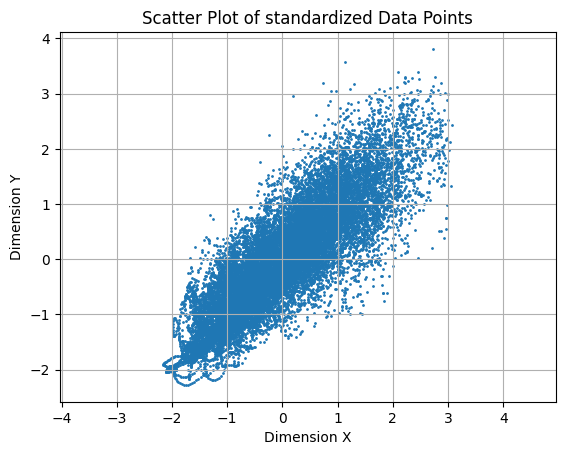

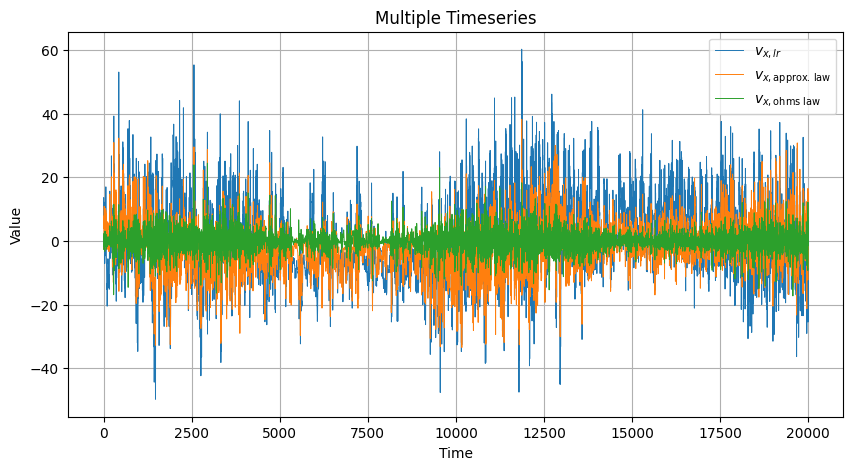

In [ ]:


# pdm
v_x_pdm = approx_part_phi_y / B_z  # pdm = potential difference method
print(f"mse(pdm) = {mean_squared_error(v_x_center, v_x_pdm)}")
print()

# pdm with c correction factor (= LR without bias)
model = LinearRegression(fit_intercept=False)
model.fit(
    X = v_x_pdm.reshape((-1, 1)),
    y = v_x_center.reshape((-1, 1)),
    )
c =  1 / model.coef_[0, 0]
v_x_c_pdm = v_x_pdm / c
print(f"mse(c_pdm) = {mean_squared_error(v_x_center, v_x_c_pdm)}")
print()

# Linear Regression (LR)
model = LinearRegression()
model.fit(
    X = v_x_pdm.reshape((-1, 1)),
    y = v_x_center.reshape((-1, 1)),
    )
v_x_lr = model.predict(v_x_pdm.reshape((-1, 1)))
print(f"mse(lr) = {mean_squared_error(v_x_center, v_x_lr)}")
print()

# Covariance
v_x_pdm_norm = (v_x_pdm - np.mean(v_x_pdm)) / np.std(v_x_pdm)
v_x_center_norm = (v_x_center - np.mean(v_x_center)) / np.std(v_x_center)
_data = np.concatenate((v_x_pdm_norm, v_x_center_norm), axis=1).T
covariance_matrix = np.cov(_data)
print("covariance_matrix(v_x_pdm_norm, v_x_center_norm):")
print(covariance_matrix)
plt.scatter(
    v_x_pdm_norm,
    v_x_center_norm,
    s=1,
    )
plt.title('Scatter Plot of standardized Data Points')
plt.xlabel('Dimension X')
plt.ylabel('Dimension Y')
plt.grid(True)
plt.axis('equal')  # Equal scaling for both axes
plt.show()

plot_timeseries(
    [
        # v_x_center - v_x_pdm,
        # v_x_center - v_x_c_pdm,
        v_x_center - v_x_lr,
        v_x_center - v_x_approx_law,
        v_x_center - v_x_ohms_law,
        ],
    labels=[
        # "v_x_pdm",
        # "v_x_c_lr",
        "$v_{x, lr}$",
        "$v_{x,\\text{approx. law}}$",
        "$v_{x, \\text{ohms law}}$",
        ],
    linewidth=0.7,
    )

##### Without Voltage Approximation

mse(ohm's law) = 7.977970680612163

mse(approx_law) = 55.980824701227434

mse(pdm) = 332.1348498632144

mse(c_pdm) = 103.84325393274713

mse(lr) = 76.98128415582886

covariance_matrix(v_x_pdm_norm, v_x_center_norm):
[[1.00005    0.91342626]
 [0.91342626 1.00005   ]]


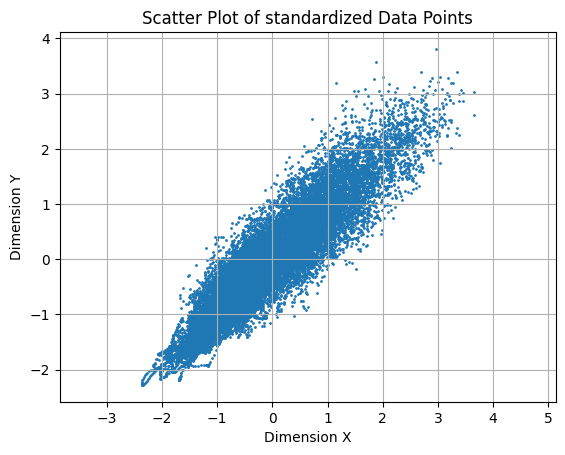

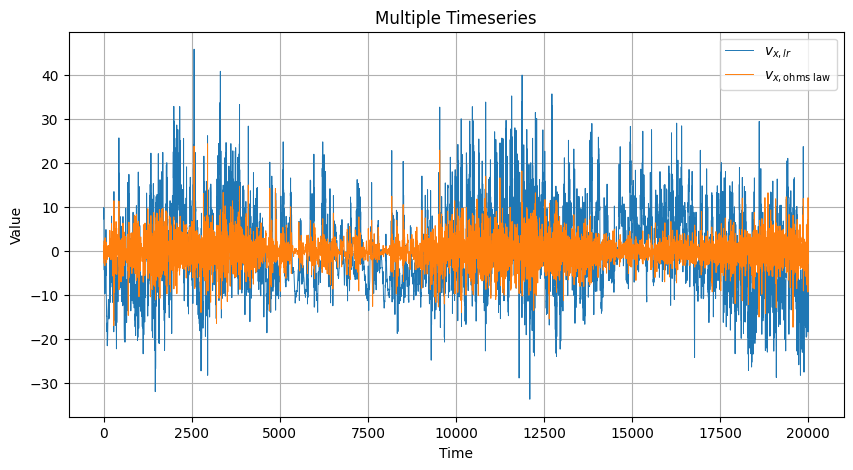

In [54]:
# known j_y + part_phi_y
v_x_ohms_law = (part_phi_y - (j_y_center / sigma)) / B_z
print(f"mse(ohm's law) = {mean_squared_error(v_x_center, v_x_ohms_law)}")
print()

# known j_y + approx_part_phi_y
v_x_approx_law = (approx_part_phi_y - (j_y_center / sigma)) / B_z
print(f"mse(approx_law) = {mean_squared_error(v_x_center, v_x_approx_law)}")
print()

# pdm
v_x_pdm = part_phi_y / B_z  # pdm = potential difference method
print(f"mse(pdm) = {mean_squared_error(v_x_center, v_x_pdm)}")
print()

# pdm with c correction factor (= LR without bias)
model = LinearRegression(fit_intercept=False)
model.fit(
    X = v_x_pdm.reshape((-1, 1)),
    y = v_x_center.reshape((-1, 1)),
    )
c =  1 / model.coef_[0, 0]
v_x_c_pdm = v_x_pdm / c
print(f"mse(c_pdm) = {mean_squared_error(v_x_center, v_x_c_pdm)}")
print()

# Linear Regression (LR)
model = LinearRegression()
model.fit(
    X = v_x_pdm.reshape((-1, 1)),
    y = v_x_center.reshape((-1, 1)),
    )
v_x_lr = model.predict(v_x_pdm.reshape((-1, 1)))
print(f"mse(lr) = {mean_squared_error(v_x_center, v_x_lr)}")
print()

# Covariance
v_x_pdm_norm = (v_x_pdm - np.mean(v_x_pdm)) / np.std(v_x_pdm)
v_x_center_norm = (v_x_center - np.mean(v_x_center)) / np.std(v_x_center)
_data = np.concatenate((v_x_pdm_norm, v_x_center_norm), axis=1).T
covariance_matrix = np.cov(_data)
print("covariance_matrix(v_x_pdm_norm, v_x_center_norm):")
print(covariance_matrix)
plt.scatter(
    v_x_pdm_norm,
    v_x_center_norm,
    s=1,
    )
plt.title('Scatter Plot of standardized Data Points')
plt.xlabel('Dimension X')
plt.ylabel('Dimension Y')
plt.grid(True)
plt.axis('equal')  # Equal scaling for both axes
plt.show()

plot_timeseries(
    [
        # v_x_center - v_x_pdm,
        # v_x_center - v_x_c_pdm,
        v_x_center - v_x_lr,
        v_x_center - v_x_ohms_law,
        ],
    labels=[
        # "v_x_pdm",
        # "v_x_c_lr",
        "$v_{x, lr}$",
        "$v_{x, \\text{ohms law}}$",
        ],
    linewidth=0.7,
    )

### Comparing $\frac{\Delta{\phi}}{\Delta{y}}$ and $j_y$

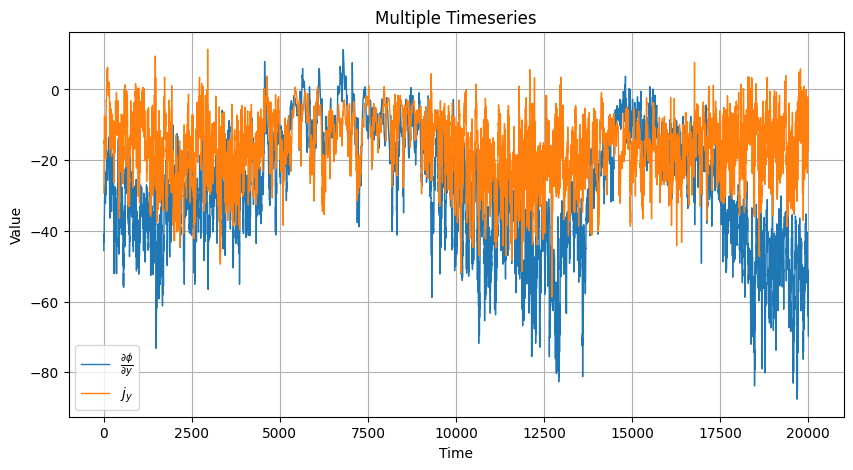

In [55]:
plot_timeseries(
    [
        part_phi_y,
        j_y_center,
        ],
    labels=[
        "$\\frac{\\partial{\\phi}}{\\partial{y}}$",
        "$j_{y}$",
        ],
    linewidth=1,
    )

## Ohm's Law in z-coord

### Voltage (Potential Difference) $\Phi$

##### Real Voltage

This one can not be measured directly by the potential probe.

In [56]:
part_phi_z = extract_timeseries(
    data=gradF_data,
    column_labels="dfdz",
    y_coord=y_coord,
    z_coord=z_coord,
    )

##### Approx Voltage with Symmetric Difference Quotient

In [57]:
"""Get indices for symmetric difference quotient points.

z_1_y = (z_1_y, z_1_z)
z_2_y = (z_2_y, z_2_z)
z_1_y = y_coord = z_2_y
z_1_z < z_coord < z_2_z

"""

delta_l = 0.1  # y, z domain = [-1, 1]

print(f"Center: y = {fld_timeseries[0][i_center][0]}, z = {fld_timeseries[0][i_center][1]}")


# Find z_1
z_1_y_desired = y_coord
z_1_z_desired = z_coord - delta_l / 2

# Adjust according to error message. No error will be thrown after correct adjustment.
# z_1_y = z_1_y_desired
# z_1_z = z_1_z_desired
if Ha == 300:
    z_1_y = -0.01842125
    z_1_z = -0.05560156
elif Ha == 1000:
    z_1_y = 0
    z_1_z = -0.03460649

i_z_1 = find_matching_row_index_from_timeseries(
    fld_timeseries,
    y_coord=z_1_y,
    z_coord=z_1_z,
    )

print(f"z_1 Coordinates: y = {z_1_y}, z = {z_1_z}")
print(f"Difference to center: delta_y^z_1 = {z_1_y - y_coord}, ", end='')
print(f"delta_z^z_1 = {z_1_z - z_coord}, delta_i^z_1 = {i_z_1 - i_center}")


# Find z_2
z_2_y_desired = y_coord
z_2_z_desired = z_coord + delta_l / 2

# Adjust according to error message. No error will be thrown after correct adjustment.
# z_2_y = z_2_y_desired
# z_2_z = z_2_z_desired
if Ha == 300:
    z_2_y = -0.01842125
    z_2_z = 0.01842125
elif Ha == 1000:
    z_2_y = 0
    z_2_z = 0.03460649

i_z_2 = find_matching_row_index_from_timeseries(
    fld_timeseries,
    y_coord=z_2_y,
    z_coord=z_2_z,
    )

print(f"z_2 Coordinates: y = {z_2_y}, z = {z_2_z}")
print(f"Difference to center: delta_y^z_2 = {z_2_y - y_coord}, ", end='')
print(f"delta_z^z_2 = {z_2_z - z_coord}, delta_i^z_2 = {i_z_2 - i_center}")


# Compare z_1 and z_2
delta_y = z_2_y - z_1_y
delta_z = z_2_z - z_1_z
print(f"Difference between z_1 to z_2: delta_y = {delta_y}, delta_z = {delta_z}, delta_i = {i_z_2 - i_z_1}")

Center: y = -0.01842125, z = -0.01842125
z_1 Coordinates: y = -0.01842125, z = -0.05560156
Difference to center: delta_y^z_1 = 0.0, delta_z^z_1 = -0.03718031, delta_i^z_1 = -46
z_2 Coordinates: y = -0.01842125, z = 0.01842125
Difference to center: delta_y^z_2 = 0.0, delta_z^z_2 = 0.0368425, delta_i^z_2 = 46
Difference between z_1 to z_2: delta_y = 0.0, delta_z = 0.07402281, delta_i = 92


In [58]:
"""Approximate Voltage with Symmetric Difference Coefficient
"""

phi_z_1 = extract_timeseries(
    data=fld_data,
    column_labels='F',
    y_coord=z_1_y,
    z_coord=z_1_z,
    )
phi_z_2 = extract_timeseries(
    data=fld_data,
    column_labels='F',
    y_coord=z_2_y,
    z_coord=z_2_z,
    )

delta_phi_z = phi_z_2 - phi_z_1
approx_part_phi_z = delta_phi_z / delta_z

##### Compare Real with Approximate Voltage $\Phi$

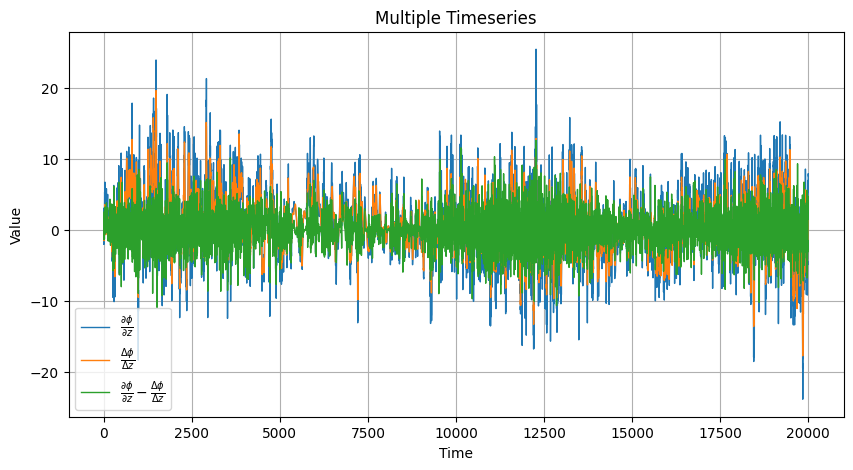

In [59]:
plot_timeseries(
    data_list=[
        part_phi_z,
        approx_part_phi_z,
        part_phi_z - approx_part_phi_z,
        ],
    labels=[
        "$\\frac{\\partial{\\phi}}{\\partial{z}}$",
        "$\\frac{\\Delta{\\phi}}{\\Delta{z}}$",
        "$\\frac{\\partial{\\phi}}{\\partial{z}} - \\frac{\\Delta{\\phi}}{\\Delta{z}}$"
        ],
    linewidth=1,
    )

### Error in z

In [60]:
j_z_center = extract_timeseries(
    data=fld_data,
    column_labels='jz',
    y_coord=y_coord,
    z_coord=z_coord,
    )

print(f"mse(part_phi_z) = {mean_squared_error(part_phi_z, j_z_center / sigma)}")

# plot_timeseries(
#     data_list=[
#         # part_phi_z,
#         part_phi_z - j_z_center / sigma_est_round,
#         ],
#     labels=[
#         # "$\\frac{\\partial{\\phi}}{\\partial{z}}$",
#         "err",
#         ],
#     linewidth=0.7,
#     )

mse(part_phi_z) = 5.858277161518981e-07
